## GPU Setting

In [15]:
import torch

# Check for MPS (Apple Silicon) or CUDA
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


# Config

In [16]:
config = {
    'dataset':{
        'train_ratio': 0.8,
        'sampling_rate': 256,
        'data_type': 'raw',
        'balance': False,
        'ictal_def': [15, 60]
    },
    'params':{
        'batch_size': 32,
        'class_weight': 0.9/0.1,
        'epoch': 80,
        'lr': 1e-4,
        'weight_decay': 0,
        'alpha': 0.7,
        'gamma': 2,
        'threshold': 0.5
    },
    'eval':{
        'metrics': 'all',
        'save_metric': 'F1_score'
    }
}

# **INPUT DATA**

## Import Tools

In [17]:
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split
import mne
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
import sys
import os
import glob
import copy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Add main directory to path to import dataset
sys.path.append('main')
# pl.seed_everything(42, workers=True) # pytorch_lightning not used in script but in original
torch.manual_seed(42)
np.random.seed(42)

## Preprocessing & Dataloader

In [18]:
# open json
patient_id = 'chb03'
with open(f"CHB_EEG/{patient_id}/seizure_time_{config['dataset']['ictal_def'][0]}_{config['dataset']['ictal_def'][1]}.json", 'r') as f:
  seizure_time = json.load(f)
items = list(seizure_time.items())

print(f"Total files found: {len(items)}")

# devide datasets for chb03
# Val: First 3 files (01-03)
# Train: Next 14 files (04-35)
# Test: Last 3 files (36-38)

train_eeg_signal = []
train_timepoints = []
print("Loading Training Data (Files 4-17)...")
for (obj, info) in items[3:17]:
  file = f"CHB_EEG/{patient_id}/{obj}.edf"
  print(f"Processing {obj}...")
  try:
      data = mne.io.read_raw_edf(file, verbose=False)
      raw_data = data.get_data()
      # Ensure 23 channels
      if raw_data.shape[0] != 23:
           if raw_data.shape[0] > 23:
               raw_data = raw_data[:23, :]
           else:
               continue
      print(raw_data.shape)
      train_eeg_signal.append(raw_data)
      train_timepoints.append((obj, info))
  except Exception as e:
      print(f"Error reading {obj}: {e}")

val_eeg_signal = []
val_timepoints = []
print("\nLoading Validation Data (Files 1-3)...")
for (obj, info) in items[:3]:
  file = f"CHB_EEG/{patient_id}/{obj}.edf"
  print(f"Processing {obj}...")
  try:
      data = mne.io.read_raw_edf(file, verbose=False)
      raw_data = data.get_data()
      if raw_data.shape[0] != 23:
           if raw_data.shape[0] > 23: raw_data = raw_data[:23, :]
           else: continue
      print(raw_data.shape)
      val_eeg_signal.append(raw_data)
      val_timepoints.append((obj, info))
  except Exception as e:
      print(f"Error reading {obj}: {e}")

test_eeg_signal = []
test_timepoints = []
print("\nLoading Test Data (Files 18-20)...")
for (obj, info) in items[17:]:
  file = f"CHB_EEG/{patient_id}/{obj}.edf"
  print(f"Processing {obj}...")
  try:
      data = mne.io.read_raw_edf(file, verbose=False)
      raw_data = data.get_data()
      if raw_data.shape[0] != 23:
           if raw_data.shape[0] > 23: raw_data = raw_data[:23, :]
           else: continue
      print(raw_data.shape)
      test_eeg_signal.append(raw_data)
      test_timepoints.append((obj, info))
  except Exception as e:
      print(f"Error reading {obj}: {e}")

Total files found: 20
Loading Training Data (Files 4-17)...
Processing chb03_04...
(23, 921600)
Processing chb03_05...
(23, 921600)
Processing chb03_06...
(23, 921600)
Processing chb03_07...
(23, 921600)
Processing chb03_08...


/var/folders/f8/c8zc8mm172s87fft_kc_0lt40000gn/T/ipykernel_47597/956257204.py:21: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  data = mne.io.read_raw_edf(file, verbose=False)
/var/folders/f8/c8zc8mm172s87fft_kc_0lt40000gn/T/ipykernel_47597/956257204.py:21: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  data = mne.io.read_raw_edf(file, verbose=False)
/var/folders/f8/c8zc8mm172s87fft_kc_0lt40000gn/T/ipykernel_47597/956257204.py:21: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  data = mne.io.read_raw_edf(file, verbose=False)
/var/folders/f8/c8zc8mm172s87fft_kc_0lt40000gn/T/ipykernel_47597/956257204.py:21: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  data = mne.io.read_raw_edf(file, verbose

(23, 921600)
Processing chb03_09...
(23, 921600)
Processing chb03_10...
(23, 921600)
Processing chb03_15...
(23, 921600)
Processing chb03_24...
(23, 921600)
Processing chb03_31...
(23, 921600)
Processing chb03_32...


/var/folders/f8/c8zc8mm172s87fft_kc_0lt40000gn/T/ipykernel_47597/956257204.py:21: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  data = mne.io.read_raw_edf(file, verbose=False)
/var/folders/f8/c8zc8mm172s87fft_kc_0lt40000gn/T/ipykernel_47597/956257204.py:21: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  data = mne.io.read_raw_edf(file, verbose=False)
/var/folders/f8/c8zc8mm172s87fft_kc_0lt40000gn/T/ipykernel_47597/956257204.py:21: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  data = mne.io.read_raw_edf(file, verbose=False)
/var/folders/f8/c8zc8mm172s87fft_kc_0lt40000gn/T/ipykernel_47597/956257204.py:21: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  data = mne.io.read_raw_edf(file, verbose

(23, 921600)
Processing chb03_33...
(23, 921600)
Processing chb03_34...
(23, 921600)
Processing chb03_35...
(23, 921600)

Loading Validation Data (Files 1-3)...
Processing chb03_01...
(23, 921600)
Processing chb03_02...


/var/folders/f8/c8zc8mm172s87fft_kc_0lt40000gn/T/ipykernel_47597/956257204.py:21: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  data = mne.io.read_raw_edf(file, verbose=False)
/var/folders/f8/c8zc8mm172s87fft_kc_0lt40000gn/T/ipykernel_47597/956257204.py:21: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  data = mne.io.read_raw_edf(file, verbose=False)
/var/folders/f8/c8zc8mm172s87fft_kc_0lt40000gn/T/ipykernel_47597/956257204.py:21: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  data = mne.io.read_raw_edf(file, verbose=False)
/var/folders/f8/c8zc8mm172s87fft_kc_0lt40000gn/T/ipykernel_47597/956257204.py:42: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  data = mne.io.read_raw_edf(file, verbose

(23, 921600)
Processing chb03_03...
(23, 921600)

Loading Test Data (Files 18-20)...
Processing chb03_36...
(23, 921600)
Processing chb03_37...
(23, 921600)
Processing chb03_38...
(23, 921600)


/var/folders/f8/c8zc8mm172s87fft_kc_0lt40000gn/T/ipykernel_47597/956257204.py:42: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  data = mne.io.read_raw_edf(file, verbose=False)
/var/folders/f8/c8zc8mm172s87fft_kc_0lt40000gn/T/ipykernel_47597/956257204.py:60: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  data = mne.io.read_raw_edf(file, verbose=False)
/var/folders/f8/c8zc8mm172s87fft_kc_0lt40000gn/T/ipykernel_47597/956257204.py:60: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  data = mne.io.read_raw_edf(file, verbose=False)
/var/folders/f8/c8zc8mm172s87fft_kc_0lt40000gn/T/ipykernel_47597/956257204.py:60: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  data = mne.io.read_raw_edf(file, verbose

In [19]:
from dataset import MFCCDataset, RawDataset

if config['dataset']['data_type'] == 'MFCC':
  # Placeholder for MFCC logic if needed, but we use raw
  pass

elif config['dataset']['data_type'] == 'raw':
  train_dataset = RawDataset(train_eeg_signal, train_timepoints, mode='train', balance=config['dataset']['balance'])
  val_dataset = RawDataset(val_eeg_signal, val_timepoints, mode='val')
  test_dataset = RawDataset(test_eeg_signal, test_timepoints, mode='test')

print("Before downsampling:")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Before downsampling:
Train: 8018, Val: 304, Test: 1620


In [20]:
# Downsample negative samples to balance the dataset (1:1 ratio)
def downsample_negative_samples(dataset, random_seed=42):
    """
    Downsample negative samples to match the number of positive samples.
    Returns a new dataset with balanced classes.
    """
    np.random.seed(random_seed)

    # Get all labels
    labels = np.array([dataset.label[i] for i in range(len(dataset))])

    # Find indices of positive and negative samples
    pos_indices = np.where(labels == 1)[0]
    neg_indices = np.where(labels == 0)[0]

    print(f"Original - Positive: {len(pos_indices)}, Negative: {len(neg_indices)}, Ratio: {len(neg_indices)/len(pos_indices) if len(pos_indices)>0 else 0:.2f}:1")

    # If no positive samples, return original dataset
    if len(pos_indices) == 0:
        print("Warning: No positive samples found, returning original dataset")
        return dataset

    # Randomly sample negative indices to match positive count
    if len(neg_indices) > len(pos_indices):
        sampled_neg_indices = np.random.choice(neg_indices, size=len(pos_indices), replace=False)
    else:
        sampled_neg_indices = neg_indices

    # Combine positive and sampled negative indices
    balanced_indices = np.concatenate([pos_indices, sampled_neg_indices])
    np.random.shuffle(balanced_indices)  # Shuffle to mix classes

    # Create new balanced dataset
    balanced_data = [dataset.data[i] for i in balanced_indices]
    balanced_labels = [dataset.label[i] for i in balanced_indices]

    # Create a simple dataset-like object or update existing dataset
    new_dataset = copy.deepcopy(dataset)
    new_dataset.data = balanced_data
    new_dataset.label = balanced_labels
    
    # Verify balance
    balanced_labels_check = np.array(new_dataset.label)
    pos_count = np.sum(balanced_labels_check == 1)
    neg_count = np.sum(balanced_labels_check == 0)
    print(f"Balanced - Positive: {pos_count}, Negative: {neg_count}, Ratio: {neg_count/pos_count if pos_count>0 else 0:.2f}:1")

    return new_dataset

# Apply downsampling to training dataset only (keep val/test original for realistic evaluation)
print("\nDownsampling training dataset...")
train_dataset = downsample_negative_samples(train_dataset, random_seed=42)

print(f"\nAfter downsampling:")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Downsampling training dataset...
Original - Positive: 540, Negative: 7478, Ratio: 13.85:1
Balanced - Positive: 540, Negative: 540, Ratio: 1.00:1

After downsampling:
Train: 1080, Val: 304, Test: 1620


In [21]:
def normalize_per_sample(data_list):
    """Normalize each sample independently to avoid distribution shift"""
    normalized = []
    for sample in data_list:
        sample_flat = sample.flatten()
        mean = np.mean(sample_flat)
        std = np.std(sample_flat)
        if std > 1e-8:  # avoid division by zero
            normalized.append((sample - mean) / std)
        else:
            normalized.append(sample)
    return normalized

print("Normalizing data per-sample (each window independently)...")
train_dataset.data = normalize_per_sample(train_dataset.data)
val_dataset.data = normalize_per_sample(val_dataset.data)
test_dataset.data = normalize_per_sample(test_dataset.data)
print("Normalization complete")

Normalizing data per-sample (each window independently)...
Normalization complete


In [22]:
'''
X_train = np.array(train_dataset.data)
X_val   = np.array(val_dataset.data)
X_test  = np.array(test_dataset.data)

X_train = X_train.reshape(X_train.shape[0], -1)
X_val   = X_val.reshape(X_val.shape[0], -1)
X_test  = X_test.reshape(X_test.shape[0], -1)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

train_dataset.data = X_train
val_dataset.data   = X_val
test_dataset.data  = X_test
'''

'\nX_train = np.array(train_dataset.data)\nX_val   = np.array(val_dataset.data)\nX_test  = np.array(test_dataset.data)\n\nX_train = X_train.reshape(X_train.shape[0], -1)\nX_val   = X_val.reshape(X_val.shape[0], -1)\nX_test  = X_test.reshape(X_test.shape[0], -1)\n\nscaler = StandardScaler()\nX_train = scaler.fit_transform(X_train)\nX_val   = scaler.transform(X_val)\nX_test  = scaler.transform(X_test)\n\ntrain_dataset.data = X_train\nval_dataset.data   = X_val\ntest_dataset.data  = X_test\n'

In [23]:
# count positive and negative samples
labels = [train_dataset.label[i] for i in range(len(train_dataset))]
label_counts = Counter(labels)
label_counts = Counter({int(k): v for k, v in label_counts.items()})
total = sum(label_counts.values())
label_ratio = {int(k): v / total for k, v in label_counts.items()}


print(f'train dataset: {label_counts, label_ratio}')
labels = [val_dataset.label[i] for i in range(len(val_dataset))]
label_counts = Counter(labels)
label_counts = Counter({int(k): v for k, v in label_counts.items()})
total = sum(label_counts.values())
label_ratio = {int(k): v / total for k, v in label_counts.items()}


print(f'val dataset: {label_counts, label_ratio}')
labels = [test_dataset.label[i] for i in range(len(test_dataset))]
label_counts = Counter(labels)
label_counts = Counter({int(k): v for k, v in label_counts.items()})
total = sum(label_counts.values())
label_ratio = {int(k): v / total for k, v in label_counts.items()}

print(f'test dataset: {label_counts, label_ratio}')

train dataset: (Counter({0: 540, 1: 540}), {0: 0.5, 1: 0.5})
val dataset: (Counter({1: 304}), {1: 1.0})
test dataset: (Counter({0: 1440, 1: 180}), {1: 0.1111111111111111, 0: 0.8888888888888888})


In [24]:
train_loader = DataLoader(train_dataset, batch_size=config['params']['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config['params']['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config['params']['batch_size'], shuffle=False)

## DCNN_BiLSTM

In [25]:
class DCNN_BiLSTM(nn.Module):
    def __init__(self, input_channels=23, input_time=1280):
        super(DCNN_BiLSTM, self).__init__()

        # 1. DCNN Front-end
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(3, 2), stride=1, padding=(1, 0)),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=(3, 2), stride=1, padding=(1, 0)),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=(3, 2), stride=1, padding=(1, 0)),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=(3, 2), stride=1, padding=(1, 0)),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        self.pool = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))

        self.dropout2d = nn.Dropout2d(p=0.1)

        # 2. Calculate CNN output dimensions
        with torch.no_grad():
            dummy_x = torch.zeros(1, 1, input_channels, input_time)
            x = self.conv1(dummy_x)
            x = self.pool(x)
            x = self.conv2(x)
            x = self.pool(x)
            x = self.conv3(x)
            x = self.pool(x)
            x = self.conv4(x)
            self.lstm_input_size = x.shape[1] * x.shape[2] 
            self.lstm_seq_len = x.shape[3]
            print(f"CNN Output Shape: {x.shape}")
            print(f"LSTM Input Features: {self.lstm_input_size}, Seq Len: {self.lstm_seq_len}")

        # 3. Bi-LSTM Back-end
        self.lstm = nn.LSTM(
            input_size=self.lstm_input_size, 
            hidden_size=8, 
            num_layers=1, 
            bidirectional=True, 
            batch_first=True
        )

        # 4. Classifier
        self.fc = nn.Sequential(
            nn.Linear(8 * 2, 1) 
        )
        
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        # 1. Dimension adjustment: (B, C, T) -> (B, 1, C, T)
        x = x.unsqueeze(1)

        # 2. DCNN Feature Extraction
        x = self.conv1(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.pool(x)
        x = self.conv3(x)
        x = self.pool(x)
        x = self.conv4(x)

        # 3. Reshape for LSTM
        x = x.permute(0, 3, 1, 2) # (Batch, W, 32, H)
        x = x.reshape(x.size(0), x.size(1), -1) # (Batch, W, 32*H)

        # 4. Bi-LSTM Processing
        lstm_out, _ = self.lstm(x)

        # 5. Take last time step
        x = lstm_out[:, -1, :] 
        
        x = self.dropout(x)

        # 6. Classification
        x = self.fc(x)
        return x

# **Training Pipeline**

In [26]:
# Model Setup
model = DCNN_BiLSTM().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config['params']['lr'], weight_decay=config['params']['weight_decay'])

best_f1 = 0.0
best_loss = float('inf')

# History tracking
history = {
    'train_loss': [], 'val_loss': [],
    'train_f1': [], 'val_f1': []
}

print("\nStarting training...")
for epoch in range(config['params']['epoch']):
    model.train()
    train_loss = 0
    train_preds = []
    train_targets = []
    
    for batch_data, batch_labels in train_loader:
        inputs = batch_data.float().to(device)
        labels = batch_labels.float().to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(), labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        probs = torch.sigmoid(outputs).squeeze()
        preds = (probs > config['params']['threshold']).float()
        train_preds.extend(preds.cpu().detach().numpy())
        train_targets.extend(labels.cpu().detach().numpy())
        
    train_loss /= len(train_loader)
    train_acc = accuracy_score(train_targets, train_preds)
    train_f1 = f1_score(train_targets, train_preds, zero_division=0)
    
    # Validation
    model.eval()
    val_loss = 0
    val_preds = []
    val_targets = []
    
    with torch.no_grad():
        for batch_data, batch_labels in val_loader:
            inputs = batch_data.float().to(device)
            labels = batch_labels.float().to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels)
            val_loss += loss.item()
            
            probs = torch.sigmoid(outputs).squeeze()
            preds = (probs > config['params']['threshold']).float()
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())
    
    val_loss /= len(val_loader)
    val_f1 = f1_score(val_targets, val_preds, zero_division=0)
    
    # Update history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    
    print(f"Epoch {epoch+1}/{config['params']['epoch']} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} F1: {train_f1:.4f} | Val Loss: {val_loss:.4f} F1: {val_f1:.4f}")
    
    # Save Best Models
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save({'state_dict': model.state_dict()}, "best_model_chb03.pth")
        print("  Saved best_model_chb03.pth (Best F1)")
        
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save({'state_dict': model.state_dict()}, "best_loss_model_chb03.pth")
        print("  Saved best_loss_model_chb03.pth (Best Loss)")

CNN Output Shape: torch.Size([1, 32, 2, 158])
LSTM Input Features: 64, Seq Len: 158

Starting training...
Epoch 1/80 | Train Loss: 0.6836 Acc: 0.5991 F1: 0.5949 | Val Loss: 0.7411 F1: 0.2825
  Saved best_model_chb03.pth (Best F1)
  Saved best_loss_model_chb03.pth (Best Loss)
Epoch 2/80 | Train Loss: 0.6664 Acc: 0.6796 F1: 0.6698 | Val Loss: 0.7471 F1: 0.2921
  Saved best_model_chb03.pth (Best F1)
Epoch 3/80 | Train Loss: 0.6435 Acc: 0.7639 F1: 0.7458 | Val Loss: 0.7833 F1: 0.2170
Epoch 4/80 | Train Loss: 0.6168 Acc: 0.8009 F1: 0.7852 | Val Loss: 0.7938 F1: 0.3523
  Saved best_model_chb03.pth (Best F1)
Epoch 5/80 | Train Loss: 0.5810 Acc: 0.8509 F1: 0.8465 | Val Loss: 0.8451 F1: 0.3830
  Saved best_model_chb03.pth (Best F1)
Epoch 6/80 | Train Loss: 0.5560 Acc: 0.8435 F1: 0.8407 | Val Loss: 0.8268 F1: 0.4800
  Saved best_model_chb03.pth (Best F1)
Epoch 7/80 | Train Loss: 0.5240 Acc: 0.8685 F1: 0.8655 | Val Loss: 0.9296 F1: 0.3958
Epoch 8/80 | Train Loss: 0.4918 Acc: 0.8870 F1: 0.8860 | V


Generating training plots...


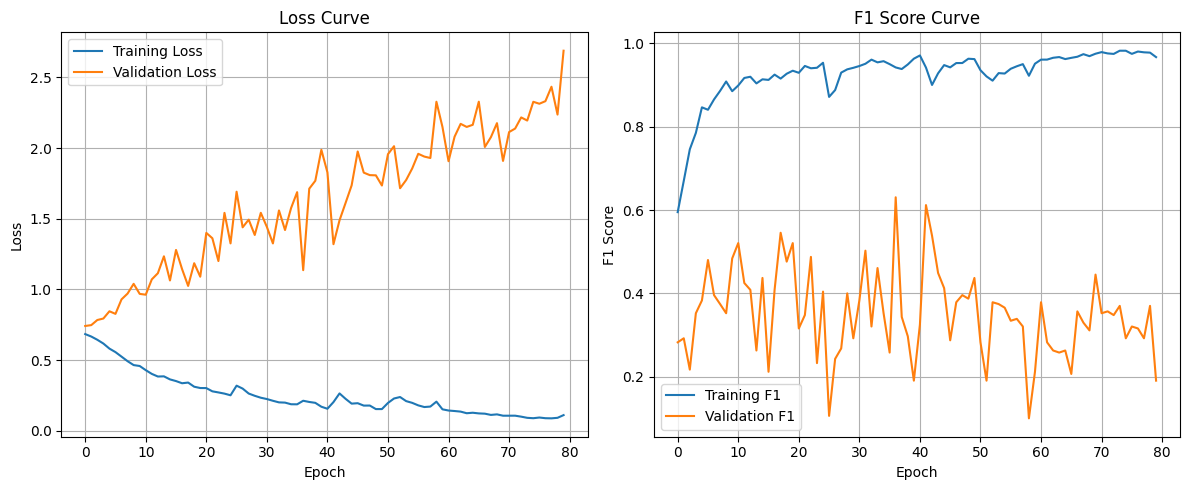

<Figure size 640x480 with 0 Axes>

In [27]:
# Plotting
print("\nGenerating training plots...")
plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# F1 Curve
plt.subplot(1, 2, 2)
plt.plot(history['train_f1'], label='Training F1')
plt.plot(history['val_f1'], label='Validation F1')
plt.title('F1 Score Curve')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
plt.savefig('training_curves_chb03.png')

## Test Evaluation

In [28]:
# Final Test Evaluation
print("\n" + "="*30)
print("FINAL TEST EVALUATION (Test Split)")
print("="*30)

# Load best model
print("Loading best_model_chb03.pth for testing...")
checkpoint = torch.load("best_model_chb03.pth", map_location=device)
model.load_state_dict(checkpoint['state_dict'])
model.eval()

test_preds = []
test_targets = []
test_probs = []

with torch.no_grad():
    for batch_data, batch_labels in test_loader:
        inputs = batch_data.float().to(device)
        labels = batch_labels.float().to(device)
        
        outputs = model(inputs)
        probs = torch.sigmoid(outputs).squeeze()
        
        if probs.ndim == 0:
            probs = probs.unsqueeze(0)
            
        preds = (probs > config['params']['threshold']).float()
        
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(labels.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())
        
acc = accuracy_score(test_targets, test_preds)
f1 = f1_score(test_targets, test_preds, zero_division=0)
try:
    auc = roc_auc_score(test_targets, test_probs)
except:
    auc = 0.0

tn, fp, fn, tp = confusion_matrix(test_targets, test_preds).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"Test Accuracy:    {acc:.4f}")
print(f"Test F1 Score:    {f1:.4f}")
print(f"Test AUC:         {auc:.4f}")
print(f"Test Specificity: {specificity:.4f}")
print(f"Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print("="*30)


FINAL TEST EVALUATION (Test Split)
Loading best_model_chb03.pth for testing...
Test Accuracy:    0.3574
Test F1 Score:    0.2527
Test AUC:         0.9551
Test Specificity: 0.2799
Confusion Matrix: TN=403, FP=1037, FN=4, TP=176
